In [1]:
import os

from IPython.utils.terminal import restore_term_title
from matplotlib import pyplot as plt
from rich import color

from deer.utils.plots import plot_steps, get_plot_data

In [44]:
path = '../traces/python_project2/'
traces_files = list(filter(lambda s: s.endswith(".trace"), os.listdir(path)))
traces_files = [os.path.join(path, file) for file in traces_files]
print(f"Se encontraron {len(traces_files)}")

Se encontraron 11


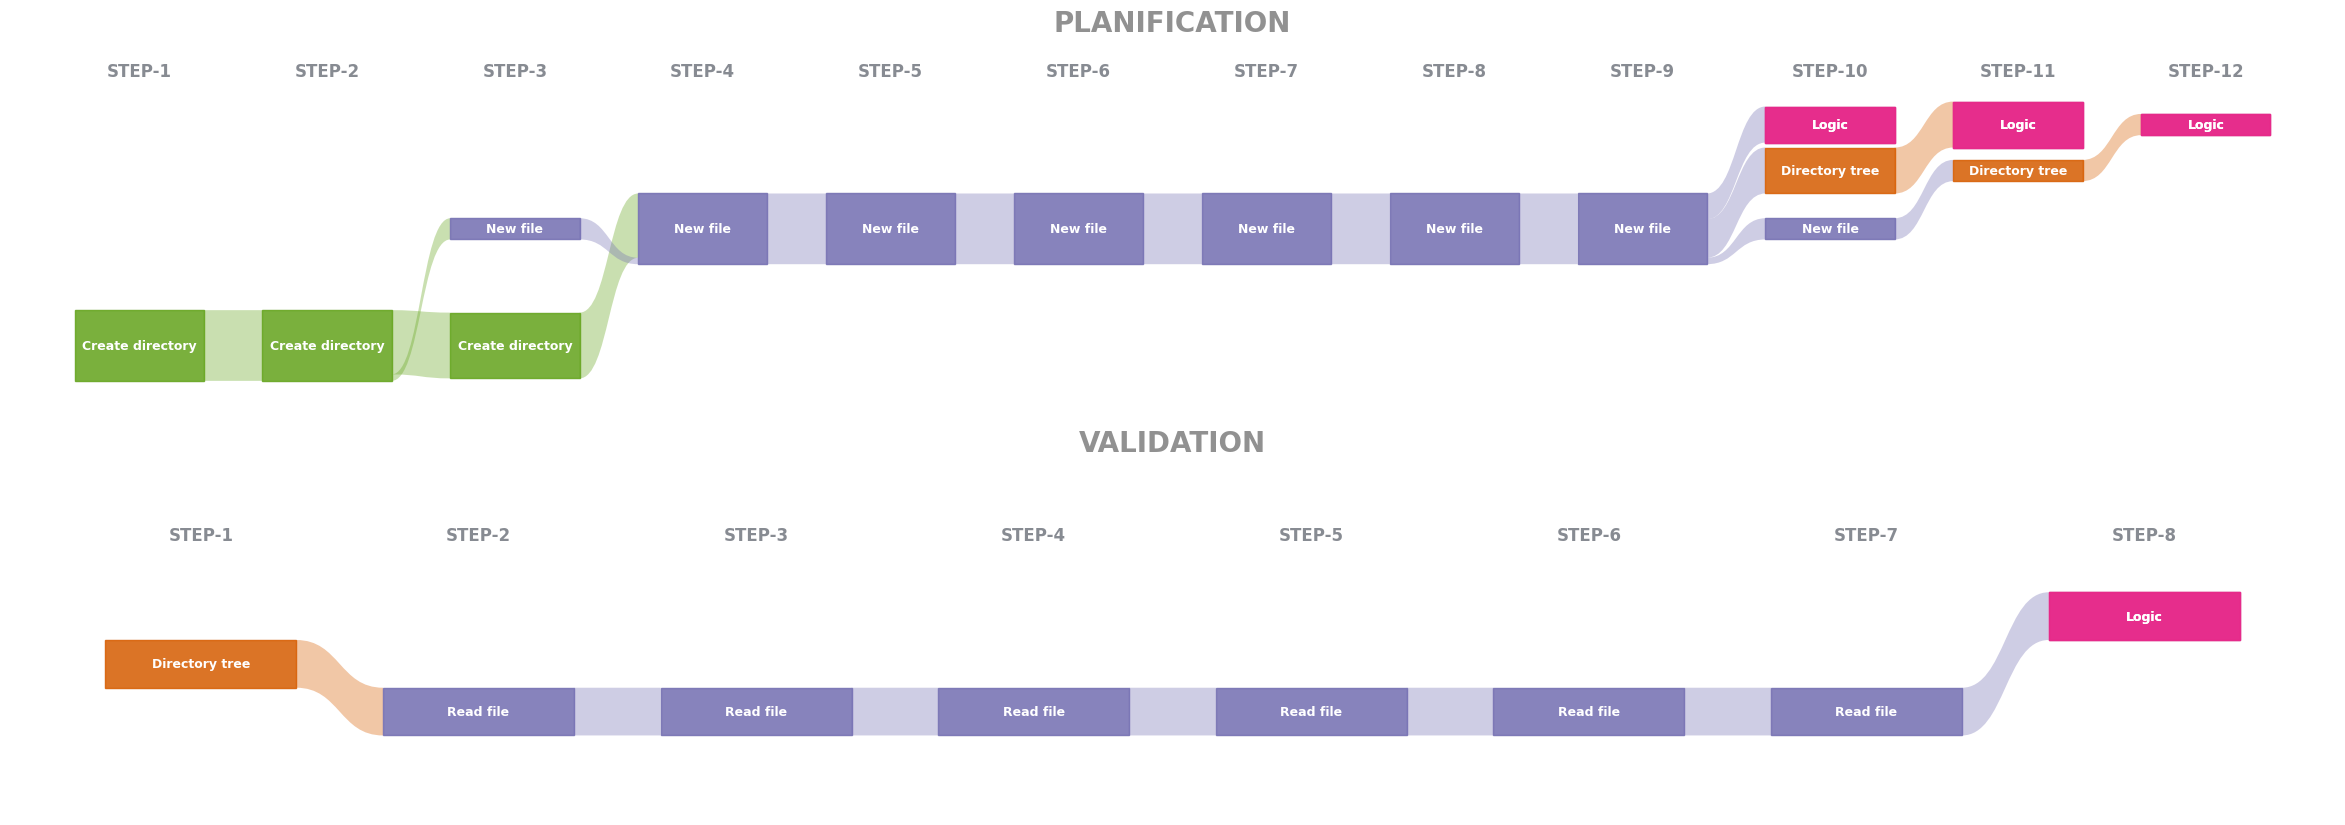

In [45]:
data = get_plot_data(traces_files, 1)

fig = plt.figure(figsize=(30, 10))
plot_steps(fig, *data, color_map_name='Dark2', font_color='#ffffff')
plt.show()

In [46]:
from collections import Counter

In [47]:

def count_traces(data):
    conteo = Counter(tuple(sublista) for sublista in data)
    conteo_ordenado = conteo.most_common()
    nombres_ejes = [f"Path {i+1}" for i in range(len(conteo_ordenado))]
    frecuencias = [cantidad for estructura, cantidad in conteo_ordenado]
    return nombres_ejes, [100 * f/sum(frecuencias) for f in frecuencias]



Text(0.5, 1.0, 'Validation paths')

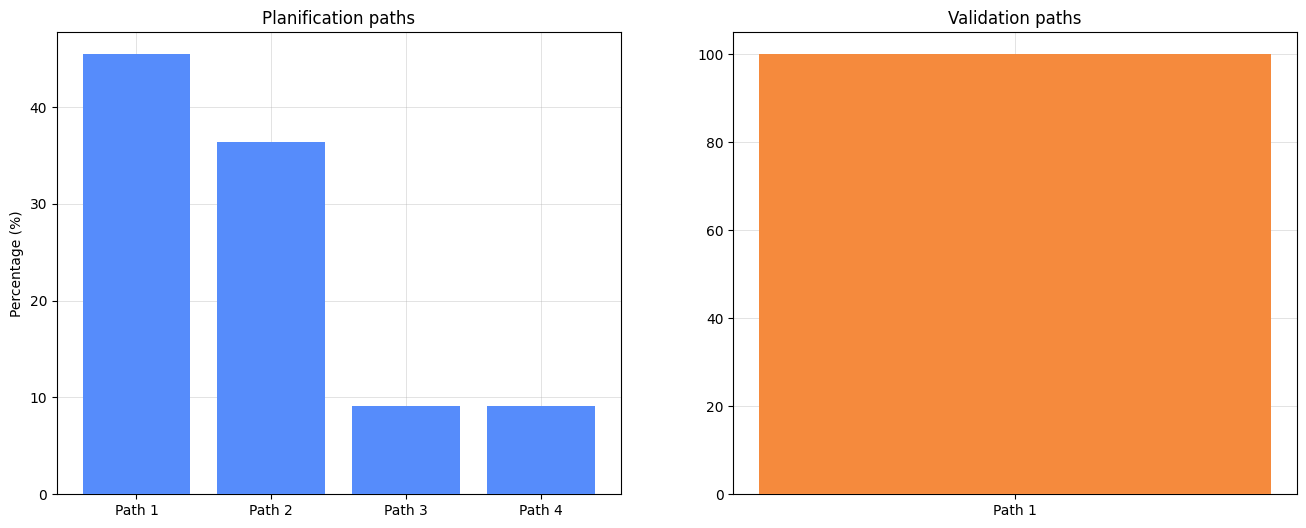

In [48]:
plt.figure(figsize=(16, 6))

plt.subplot(121)
plt.grid(True, zorder=-1)
plt.bar(*count_traces(data[0]), zorder=99, color='C0')
plt.title("Planification paths")
plt.ylabel("Percentage (%)")

plt.subplot(122)
plt.grid(True, zorder=-1)
plt.bar(*count_traces(data[1]), zorder=99, color='C1')
plt.title("Validation paths")